In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


=== Missing Values per Column ===
id                         0
name                       3
album_name                20
artists                    0
danceability               0
energy                     0
key                        0
loudness                   0
mode                       0
speechiness                0
acousticness               0
instrumentalness           0
liveness                   0
valence                    0
tempo                      0
duration_ms                0
lyrics                     0
year                       0
genre                      0
popularity                 0
total_artist_followers     0
avg_artist_popularity      0
artist_ids                 0
niche_genres               0
dtype: int64
=== After Replacing Missing Values ===
name                      0
album_name                0
artists                   0
danceability              0
energy                    0
key                       0
loudness                  0
mode                  

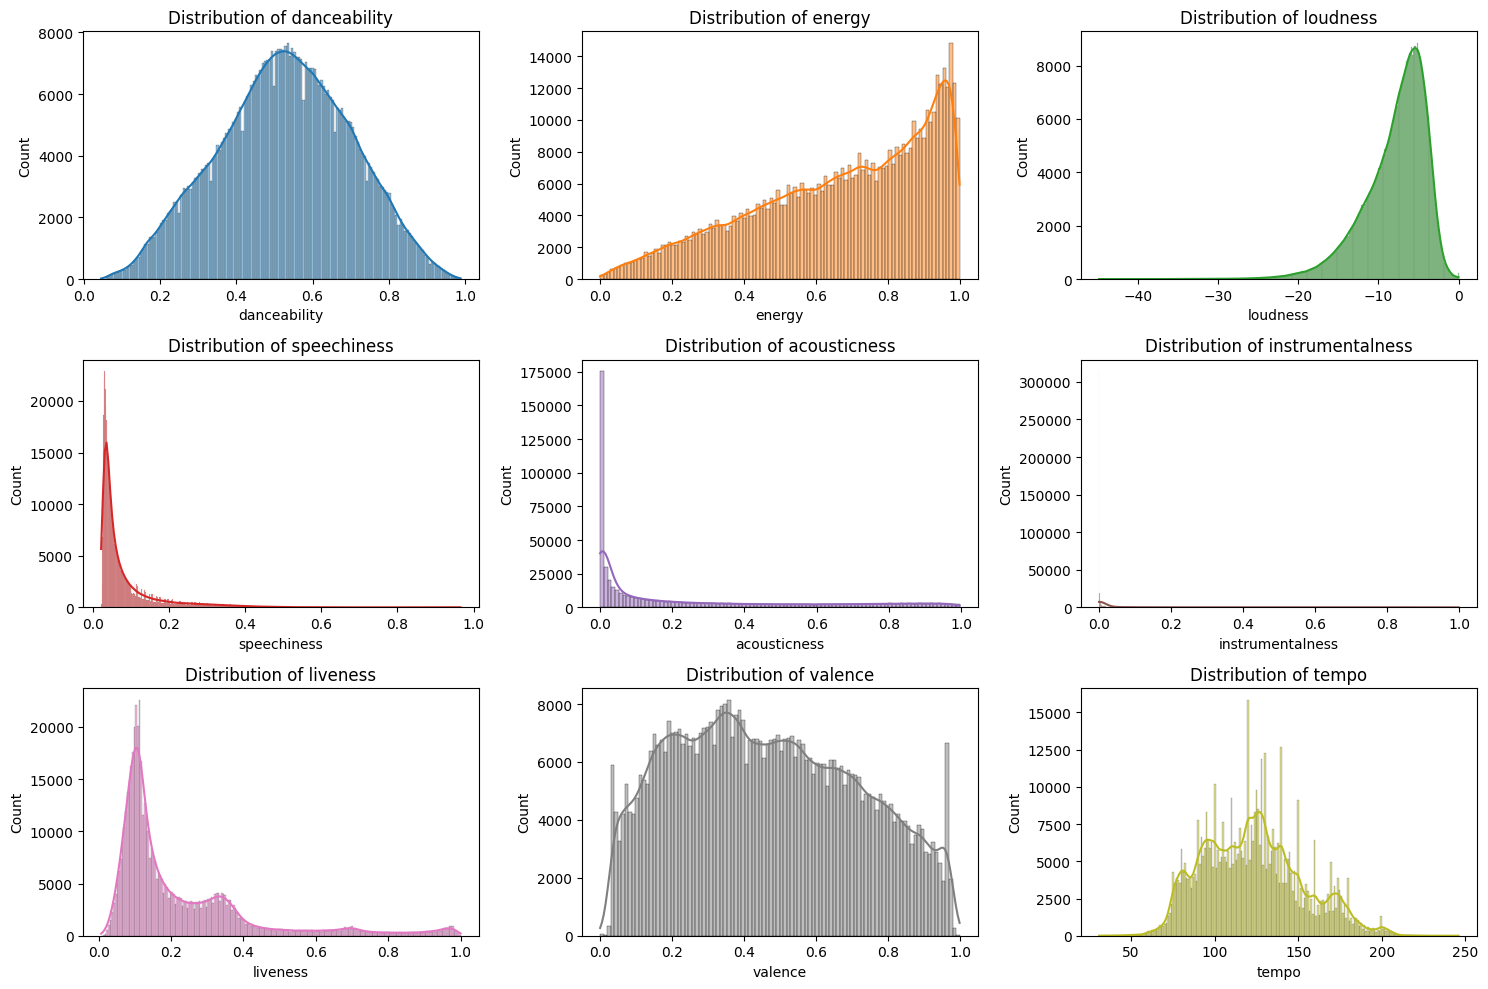

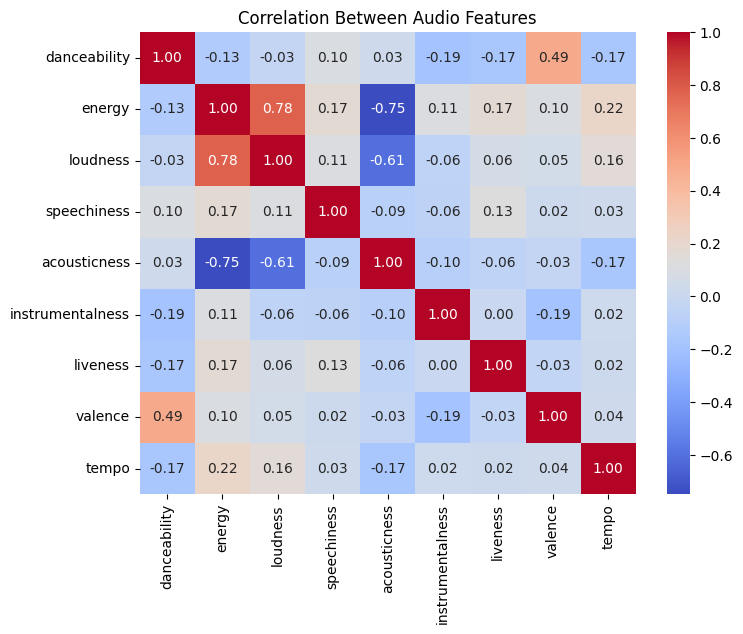

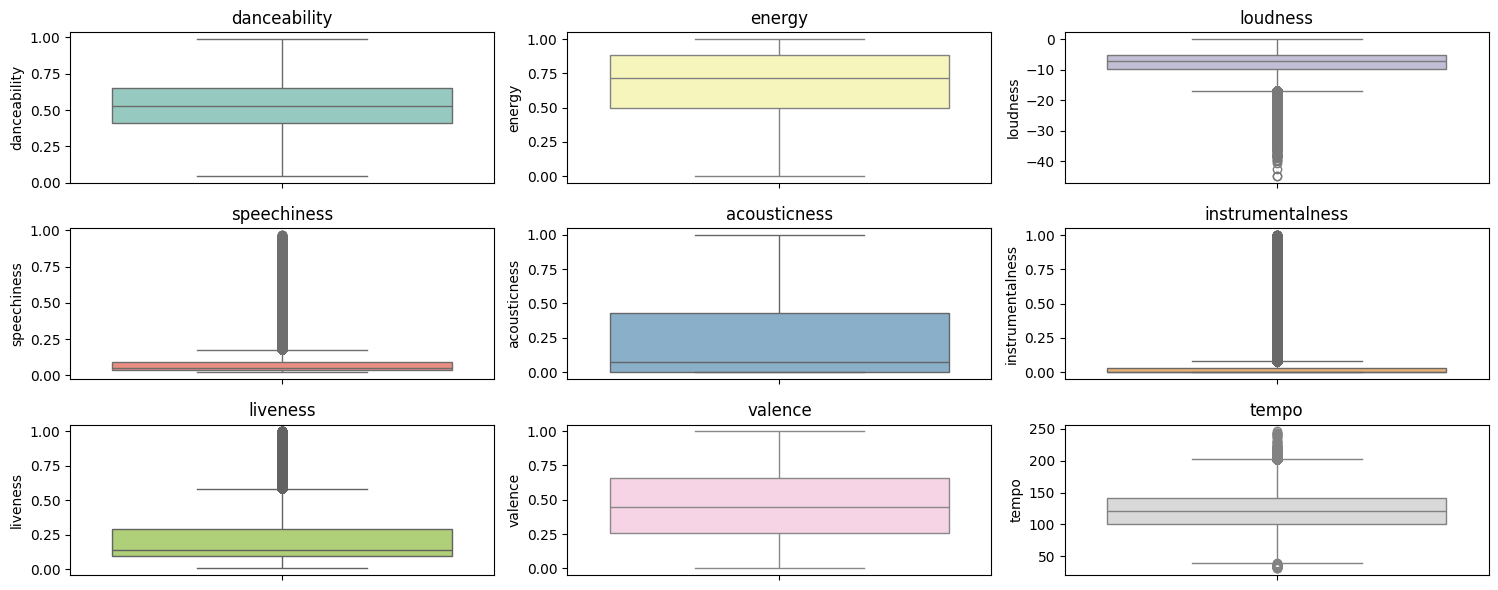

In [ ]:
# Load Dataset
df = pd.read_csv("/kaggle/input/datasets/sabrina001/550k-music-dataset/songs.csv")  

# Keep only relevant numeric/audio features for this analysis and also they are the input dimension
audio_cols = ['danceability','energy','loudness','speechiness','acousticness','instrumentalness','liveness','valence','tempo']

# Check for missing/null values
print("=== Missing Values per Column ===")
#print(df[audio_cols + ['lyrics','genre']].isnull().sum())
print(df.isnull().sum())
print("=== After Replacing Missing Values ===")

# Drop the 'id' column
df = df.drop(columns=['id'])

# Handling 'name' missing values (Replacing with "Unknown")
df['name'] = df['name'].fillna("Unknown Name")

# Handling 'album_name' missing values (Replacing with most common album)
df['album_name'] = df['album_name'].fillna(df['album_name'].mode()[0])

# Verify the results
print(df.isnull().sum())
print(df.head())

# Descriptive statistics
desc_stats = df[audio_cols].describe().T
print("=== Descriptive Statistics ===")
print(desc_stats)

# Add range (max - min) for each column
desc_stats['range'] = desc_stats['max'] - desc_stats['min']
print("\n=== Descriptive Stats with Range ===")
print(desc_stats)

# Feature Distribution Plots
plt.figure(figsize=(15,10))
for i, col in enumerate(audio_cols):
    plt.subplot(3,3,i+1)
    sns.histplot(df[col], kde=True, color=sns.color_palette("tab10")[i])
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Feature Distribution Plots (for all cols)
'''
cols = ['release_date','len']
plt.figure(figsize=(15,10))
for i, col in enumerate(cols):
    plt.subplot(1,2,i+1)
    sns.histplot(df[col], kde=True, color=sns.color_palette("tab10")[i])
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()
'''

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[audio_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Audio Features")
plt.show()

# Boxplots to check for outliers
plt.figure(figsize=(15,6))
for i, col in enumerate(audio_cols):
    plt.subplot(3,3,i+1)
    sns.boxplot(y=df[col], color=sns.color_palette("Set3")[i])
    plt.title(col)
plt.tight_layout()
plt.show()

In [3]:
# Take small subset
df = df.sample(25000, random_state=42)
print(df.shape)
df.head

(25000, 23)


<bound method NDFrame.head of                             name  \
313554             Naive Monarch   
210119  I Can't Live Without You   
136837              Erase It All   
460801              The Majestic   
19995   Ain't What It Used To Be   
...                          ...   
425787          Stone Cold Fever   
385951                Satellites   
141658      Exhaustion & Disgust   
191135                      Heat   
54212                  Big Girls   

                                               album_name  \
313554                                           Versions   
210119                           I Can't Live Without You   
136837                                          Hail Mary   
460801                         Cup of Sand (2017 Reissue)   
19995                                    Billy Currington   
...                                                   ...   
425787  20th Century Masters:The Millennium Collection...   
385951                            Periphery IV: H

In [4]:
feature_cols = [
    'danceability','energy','loudness',
    'speechiness','acousticness','instrumentalness',
    'liveness','valence','tempo'
]

X = df[feature_cols].fillna(0).values

# StandardScaler is better for clustering and clustering distance-based metrics (Silhouette, Calinski-Harabasz)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to tensor
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

# Create dataset
dataset = TensorDataset(X_tensor)

# Create DataLoader
batch_size = 64
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
# Min-Max scaling
#scaler = MinMaxScaler()
#X_scaled = scaler.fit_transform(X)

# Convert to PyTorch tensor
#X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)

# check scaled values
df_scaled = pd.DataFrame(X_scaled, columns=feature_cols)
print(df_scaled.head)

<bound method NDFrame.head of        danceability    energy  loudness  speechiness  acousticness  \
0         -0.758944  1.224340  0.995973    -0.242116     -0.788027   
1          1.030762  0.182282  0.079097    -0.453931     -0.787325   
2          0.106856  1.297610  1.142319     0.902744     -0.787835   
3         -0.944887  1.073730  1.041804    -0.249530     -0.748507   
4          0.734415  0.662606  1.044408    -0.536539     -0.366536   
...             ...       ...       ...          ...           ...   
24995     -1.078534  0.279975  0.059827    -0.316252     -0.780856   
24996      0.234692  0.275905  0.118418    -0.502649     -0.647215   
24997     -0.323139  0.878344  0.727498    -0.073723     -0.787155   
24998      1.664132 -0.143361  0.465273    -0.474054     -0.261976   
24999     -1.456232 -0.236983 -0.130006    -0.559839     -0.782686   

       instrumentalness  liveness   valence     tempo  
0             -0.447194  0.597706 -1.357518 -0.608894  
1              1.

In [5]:
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=5):
        super(VAE, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )
        
        self.mu = nn.Linear(64, latent_dim)
        self.logvar = nn.Linear(64, latent_dim)
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x):
        h = self.encoder(x)
        mu = self.mu(h)
        logvar = self.logvar(h)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar, z


In [7]:
# Hyperparameter Search
latent_dims = [5, 6, 7, 8]
learning_rates = [1e-3, 3e-3, 5e-3]
cluster_nums = [4, 5, 6]
epochs = 50

all_results = []  # store all runs to compute global min/max later

for ld in latent_dims:
    for lr in learning_rates:
        # Initialize VAE
        input_dim = X_scaled.shape[1]
        model = VAE(input_dim, latent_dim=ld).to(device)
        optimizer = optim.Adam(model.parameters(), lr=lr)
        
        # Train VAE
        for epoch in range(epochs):
            model.train()
            for (batch,) in dataloader:
                batch = batch.to(device)
                optimizer.zero_grad()
                recon, mu, logvar, z = model(batch)
                recon_loss = nn.MSELoss()(recon, batch)
                kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
                loss = recon_loss + kl_loss
                loss.backward()
                optimizer.step()
            print(f"Epoch {epoch + 1}/{epochs}, MSE Loss: {recon_loss.item():.6f}, KLD Loss: {kl_loss.item():.6f}, Total Loss: {loss.item():.6f}")

        # Extract latent features
        model.eval()
        with torch.no_grad():
           recon, mu, logvar, z = model(X_tensor.to(device))
           latent_features = mu.cpu().numpy()
        for k in cluster_nums:
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
            clusters = kmeans.fit_predict(latent_features)
            
            sil = silhouette_score(latent_features, clusters)
            ch = calinski_harabasz_score(latent_features, clusters)
            print(f"LD={ld}, LR={lr}, K={k} -> Silhouette: {sil:.4f}, CH: {ch:.2f}")

            # Store the result for later global normalization
            all_results.append({
                'latent_dim': ld,
                'learning_rate': lr,
                'n_clusters': k,
                'silhouette': sil,
                'calinski_harabasz': ch,
                'latent_features': latent_features,
                'model_state_dict': model.state_dict()  # store weights for best model
            })

# Compute global min/max across all runs
sil_values = [r['silhouette'] for r in all_results]
ch_values = [r['calinski_harabasz'] for r in all_results]
sil_min, sil_max = min(sil_values), max(sil_values)
ch_min, ch_max = min(ch_values), max(ch_values)

# Select best VAE using normalized combined score
best_score = -1
best_vae = None
for r in all_results:
    sil_norm = (r['silhouette'] - sil_min) / (sil_max - sil_min + 1e-8)
    ch_norm = (r['calinski_harabasz'] - ch_min) / (ch_max - ch_min + 1e-8)
    combined_score = sil_norm * ch_norm
    if combined_score > best_score:
        best_score = combined_score
        best_vae = r
        # Save the best model
        torch.save(r['model_state_dict'], "best_vae_model_results.pth")
        print(f"Saved best VAE model with .pth file.")

# Print best hyperparameters and scores
print("\nBest Hyperparameters & Scores:")
summary_keys_vae = ["latent_dim", "learning_rate", "n_clusters", "silhouette", "calinski_harabasz"]
print({k: best_vae[k] for k in summary_keys_vae})

Epoch 1/50, MSE Loss: 0.708480, KLD Loss: 0.191380, Total Loss: 0.899860
Epoch 2/50, MSE Loss: 0.601054, KLD Loss: 0.239627, Total Loss: 0.840681
Epoch 3/50, MSE Loss: 0.620942, KLD Loss: 0.288345, Total Loss: 0.909286
Epoch 4/50, MSE Loss: 0.644143, KLD Loss: 0.315859, Total Loss: 0.960003
Epoch 5/50, MSE Loss: 0.651696, KLD Loss: 0.252012, Total Loss: 0.903708
Epoch 6/50, MSE Loss: 0.630639, KLD Loss: 0.330839, Total Loss: 0.961479
Epoch 7/50, MSE Loss: 0.566674, KLD Loss: 0.259394, Total Loss: 0.826068
Epoch 8/50, MSE Loss: 0.628400, KLD Loss: 0.250892, Total Loss: 0.879291
Epoch 9/50, MSE Loss: 0.470607, KLD Loss: 0.267908, Total Loss: 0.738515
Epoch 10/50, MSE Loss: 0.568316, KLD Loss: 0.290720, Total Loss: 0.859037
Epoch 11/50, MSE Loss: 0.576430, KLD Loss: 0.262274, Total Loss: 0.838704
Epoch 12/50, MSE Loss: 0.606806, KLD Loss: 0.277976, Total Loss: 0.884782
Epoch 13/50, MSE Loss: 0.581852, KLD Loss: 0.314497, Total Loss: 0.896349
Epoch 14/50, MSE Loss: 0.574284, KLD Loss: 0.33

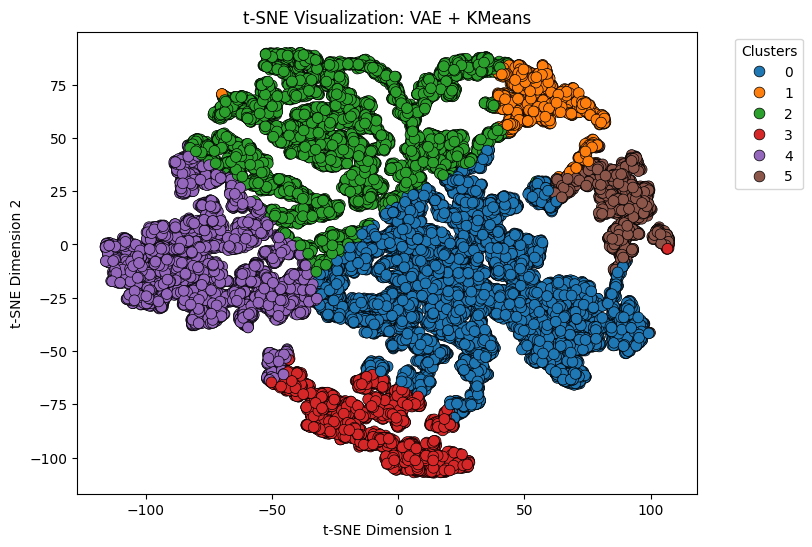

In [8]:
# Use the best number of clusters and best latent features
best_k = best_vae['n_clusters']
latent_features_best = best_vae['latent_features']  # already from the best VAE

# KMeans with best number of clusters
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
clusters_vae = kmeans.fit_predict(latent_features_best)

# Add cluster info to dataframe
df['vae_cluster'] = clusters_vae

# t-SNE for visualization
tsne = TSNE(n_components=2, perplexity=50, random_state=42)
latent_2d = tsne.fit_transform(latent_features_best)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=latent_2d[:,0],
    y=latent_2d[:,1],
    hue=clusters_vae,
    palette='tab10',
    s=60,
    edgecolor='black',
    linewidth=0.5
)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("t-SNE Visualization: VAE + KMeans")
plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

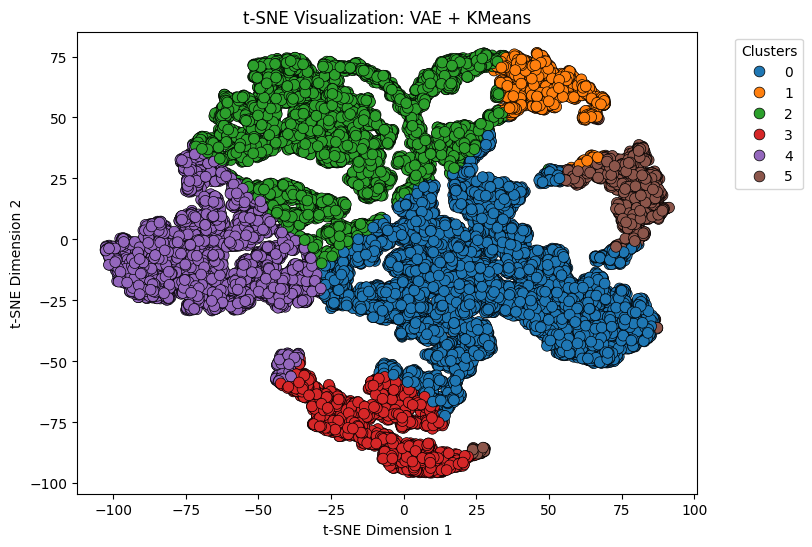

In [9]:
# Use the best number of clusters and best latent features
best_k = best_vae['n_clusters']
latent_features_best = best_vae['latent_features']  # already from the best VAE

# KMeans with best number of clusters
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
clusters_vae = kmeans.fit_predict(latent_features_best)

# Add cluster info to dataframe
df['vae_cluster'] = clusters_vae

# t-SNE for visualization
tsne = TSNE(n_components=2, perplexity=80, random_state=42)
latent_2d = tsne.fit_transform(latent_features_best)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=latent_2d[:,0],
    y=latent_2d[:,1],
    hue=clusters_vae,
    palette='tab10',
    s=60,
    edgecolor='black',
    linewidth=0.5
)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("t-SNE Visualization: VAE + KMeans")
plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

             danceability    energy  loudness  speechiness  acousticness  \
vae_cluster                                                                
0                0.428025  0.828398  0.843359     0.057659      0.055245   
1                0.678840  0.655865  0.777774     0.377575      0.247196   
2                0.674830  0.659823  0.783706     0.053856      0.233501   
3                0.408762  0.756757  0.780359     0.054554      0.138093   
4                0.456866  0.306651  0.655023     0.020537      0.703762   
5                0.385489  0.770239  0.793832     0.077325      0.192869   

             instrumentalness  liveness   valence     tempo  
vae_cluster                                                  
0                    0.049111  0.193227  0.398378  0.530687  
1                    0.007448  0.278559  0.613547  0.440214  
2                    0.019649  0.151647  0.698706  0.441478  
3                    0.766503  0.186461  0.319146  0.489582  
4                  

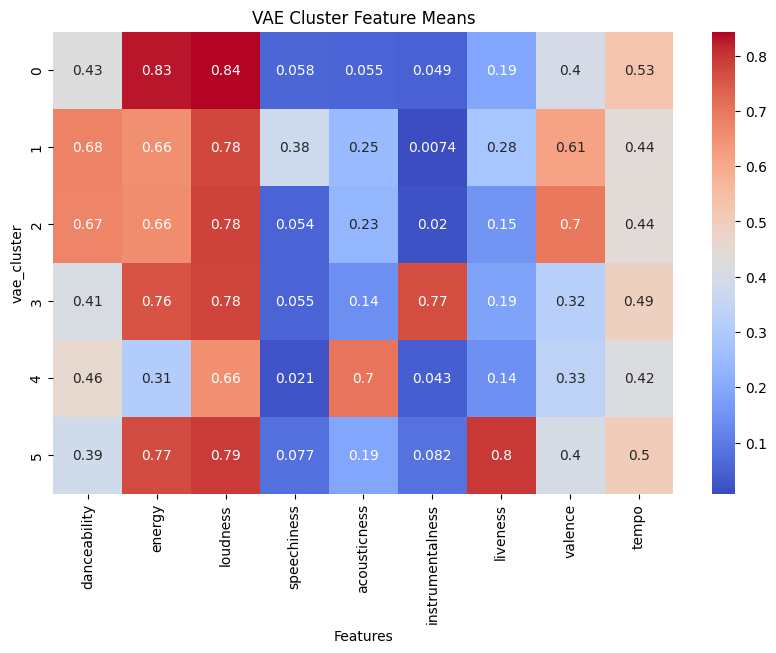

(VAE) Each Cluster Size: 


vae_cluster
0    8987
2    6462
4    4431
3    2350
5    1461
1    1309
Name: count, dtype: int64

In [23]:
scaler_mm = MinMaxScaler()
df_mm = df.copy()
df_mm[feature_cols] = scaler_mm.fit_transform(df[feature_cols])

cluster_summary_vae = df_mm.groupby('vae_cluster')[feature_cols].mean()
print(cluster_summary_vae)

# heatmap visualization
plt.figure(figsize=(10,6))
sns.heatmap(cluster_summary_vae, annot=True, cmap='coolwarm')
plt.xlabel("Features")
plt.title("VAE Cluster Feature Means")
plt.show()

# Check cluster size
print("(VAE) Each Cluster Size: ")
df['vae_cluster'].value_counts()


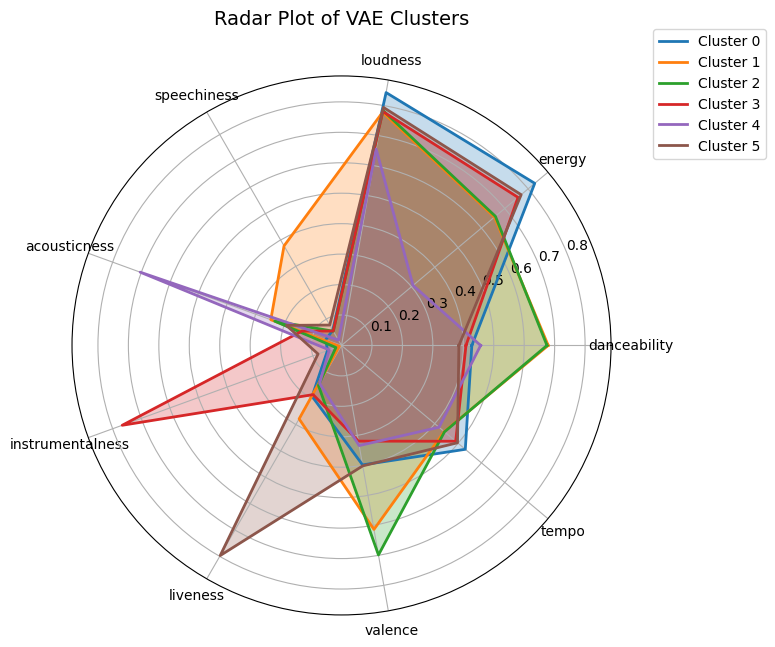

In [11]:
# Radar / Spider Plot

cluster_summary_vae = df_mm.groupby('vae_cluster')[feature_cols].mean()

labels = feature_cols
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(7,7))

colors = sns.color_palette("tab10", len(cluster_summary_vae))
for i, color in zip(cluster_summary_vae.index, colors):
    values = cluster_summary_vae.loc[i].values.tolist()
    values += values[:1]
    plt.polar(angles, values, label=f"Cluster {i}", color=color, linewidth=2)

    plt.fill(angles, values, color=color, alpha=0.25)

plt.xticks(angles[:-1], labels, rotation=45)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.title("Radar Plot of VAE Clusters", size=14, color='black', y=1.08)
plt.show()


             danceability    energy  loudness  speechiness  acousticness  \
vae_cluster                                                                
0               -0.077742  0.155215  0.061050    -0.010046     -0.186900   
1                0.173073 -0.017319 -0.004535     0.309871      0.005051   
2                0.169063 -0.013361  0.001397    -0.013849     -0.008644   
3               -0.097006  0.083573 -0.001949    -0.013151     -0.104051   
4               -0.048901 -0.366532 -0.127285    -0.047167      0.461617   
5               -0.120278  0.097055  0.011524     0.009621     -0.049276   

             instrumentalness  liveness   valence     tempo  
vae_cluster                                                  
0                   -0.058467 -0.019613 -0.070230  0.053574  
1                   -0.100130  0.065719  0.144939 -0.036898  
2                   -0.087929 -0.061194  0.230098 -0.035634  
3                    0.658924 -0.026379 -0.149462  0.012470  
4                  

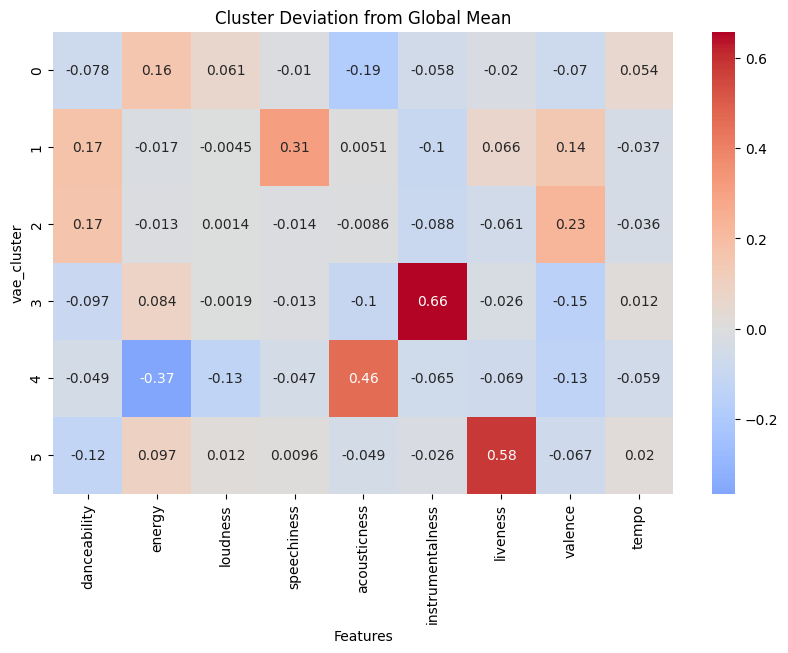

In [24]:
# Feature Importance per Cluster (Difference from Global Mean)
overall_mean = df_mm[feature_cols].mean()
diff = cluster_summary_vae - overall_mean
print(diff)

plt.figure(figsize=(10,6))
sns.heatmap(diff, annot=True, cmap='coolwarm', center=0)
plt.xlabel("Features")
plt.title("Cluster Deviation from Global Mean")
plt.show()


Min: -0.15187523
Max: 0.67166454


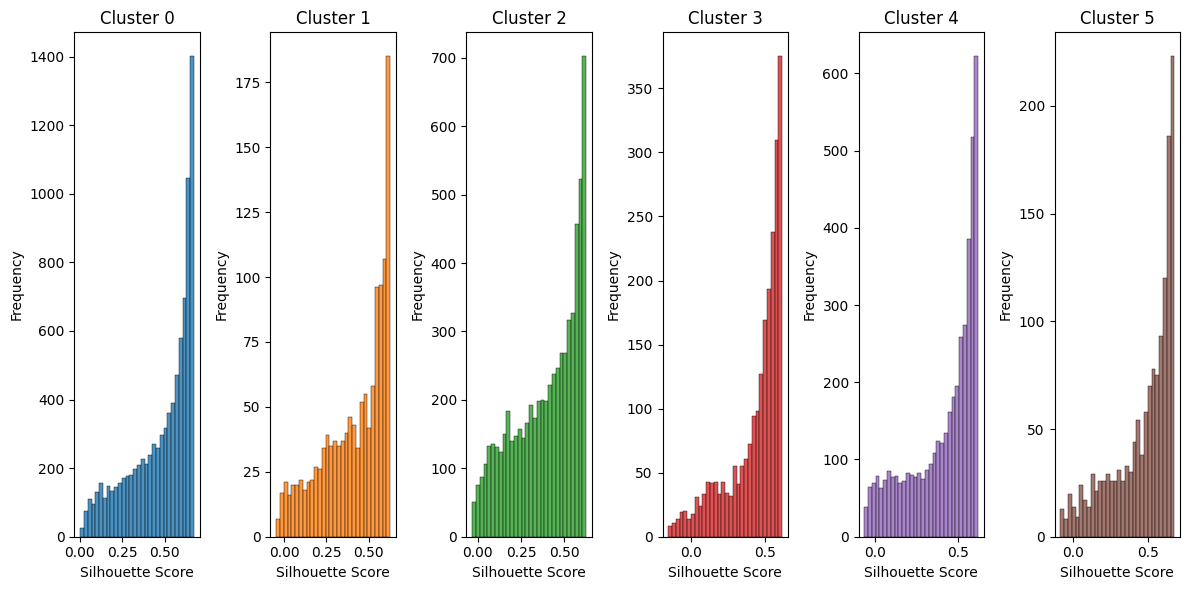

In [59]:
# Silhouette Plot (show silhouette per sample)
from sklearn.metrics import silhouette_samples
sil_vae = silhouette_samples(latent_features_best, clusters_vae)

print("Min:", sil_vae.min())
print("Max:", sil_vae.max())

unique_clusters = np.unique(clusters_vae)
colors = sns.color_palette("tab10", len(unique_clusters))

plt.figure(figsize=(12, 6))

for i, c in enumerate(unique_clusters):
    plt.subplot(1, len(unique_clusters), i+1)
    
    sns.histplot(
        sil_vae[clusters_vae == c],
        bins=30,
        color=colors[i],   
        edgecolor='black',
        alpha=0.8
    )
    
    plt.title(f'Cluster {c}')
    plt.xlabel("Silhouette Score")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


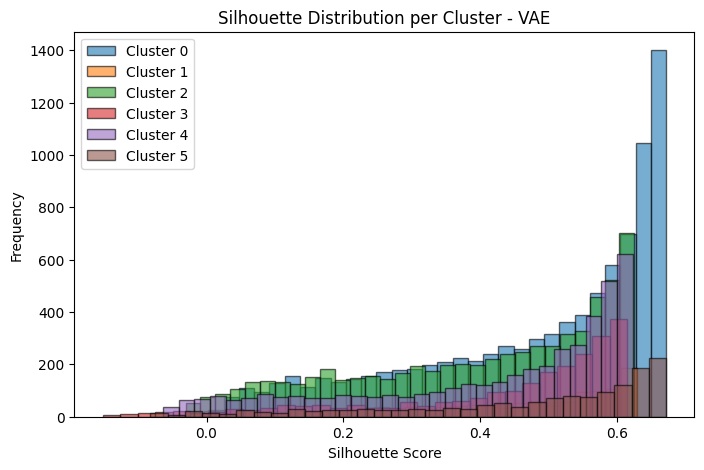

In [25]:
from sklearn.metrics import silhouette_samples

# sil_vae = silhouette_samples(latent_features_best, clusters_vae)

unique_clusters = np.unique(clusters_vae)

plt.figure(figsize=(8,5))

for c in unique_clusters:
    plt.hist(
        sil_vae[clusters_vae == c],
        bins=30,
        alpha=0.6,
        edgecolor='black',
        label=f'Cluster {c}'
    )

plt.title("Silhouette Distribution per Cluster - VAE")
plt.xlabel("Silhouette Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

Average silhouette score (red dashed line): 0.43872046
Cluster 0 average silhouette: 0.48074105
Cluster 1 average silhouette: 0.41368124
Cluster 2 average silhouette: 0.39663875
Cluster 3 average silhouette: 0.43262434
Cluster 4 average silhouette: 0.41659877
Cluster 5 average silhouette: 0.4656999


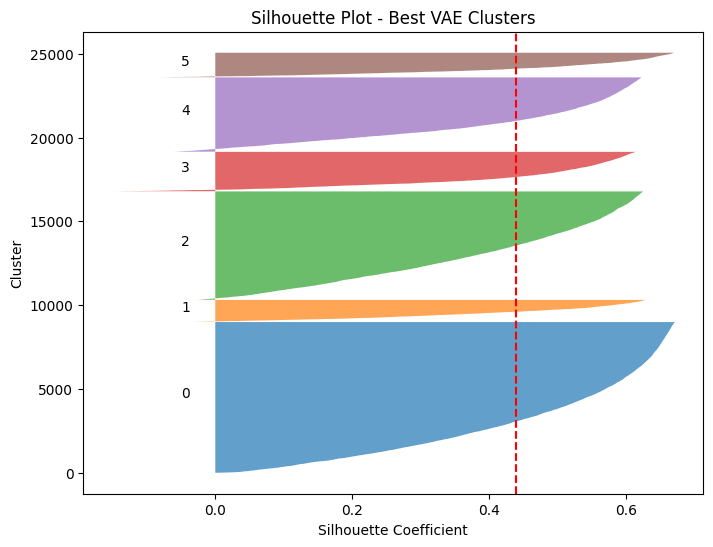

In [27]:
from sklearn.metrics import silhouette_samples

# Compute silhouette scores for the best clustering
sil_vae = silhouette_samples(latent_features_best, clusters_vae)

y_lower = 10
unique_clusters = np.unique(clusters_vae)

plt.figure(figsize=(8,6))

for c in unique_clusters:
    cluster_sil_vae = sil_vae[clusters_vae == c]
    cluster_sil_vae.sort()
    
    size_cluster = cluster_sil_vae.shape[0]
    y_upper = y_lower + size_cluster
    
    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_sil_vae,
        alpha=0.7
    )
    
    plt.text(-0.05, y_lower + 0.5 * size_cluster, str(c))
    
    y_lower = y_upper + 10

avg_silhouette = np.mean(sil_vae)
print("Average silhouette score (red dashed line):", avg_silhouette)

for c in unique_clusters:
    cluster_avg = sil_vae[clusters_vae == c].mean()
    print(f"Cluster {c} average silhouette:", cluster_avg)

plt.axvline(x=avg_silhouette, color="red", linestyle="--")
plt.title("Silhouette Plot - Best VAE Clusters")
plt.xlabel("Silhouette Coefficient")
plt.ylabel("Cluster")
plt.show()

/tmp/ipykernel_55/3012031444.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_55/3012031444.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_55/3012031444.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_55/3012031444.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_55/3012031444.py:10: FutureWarning: 


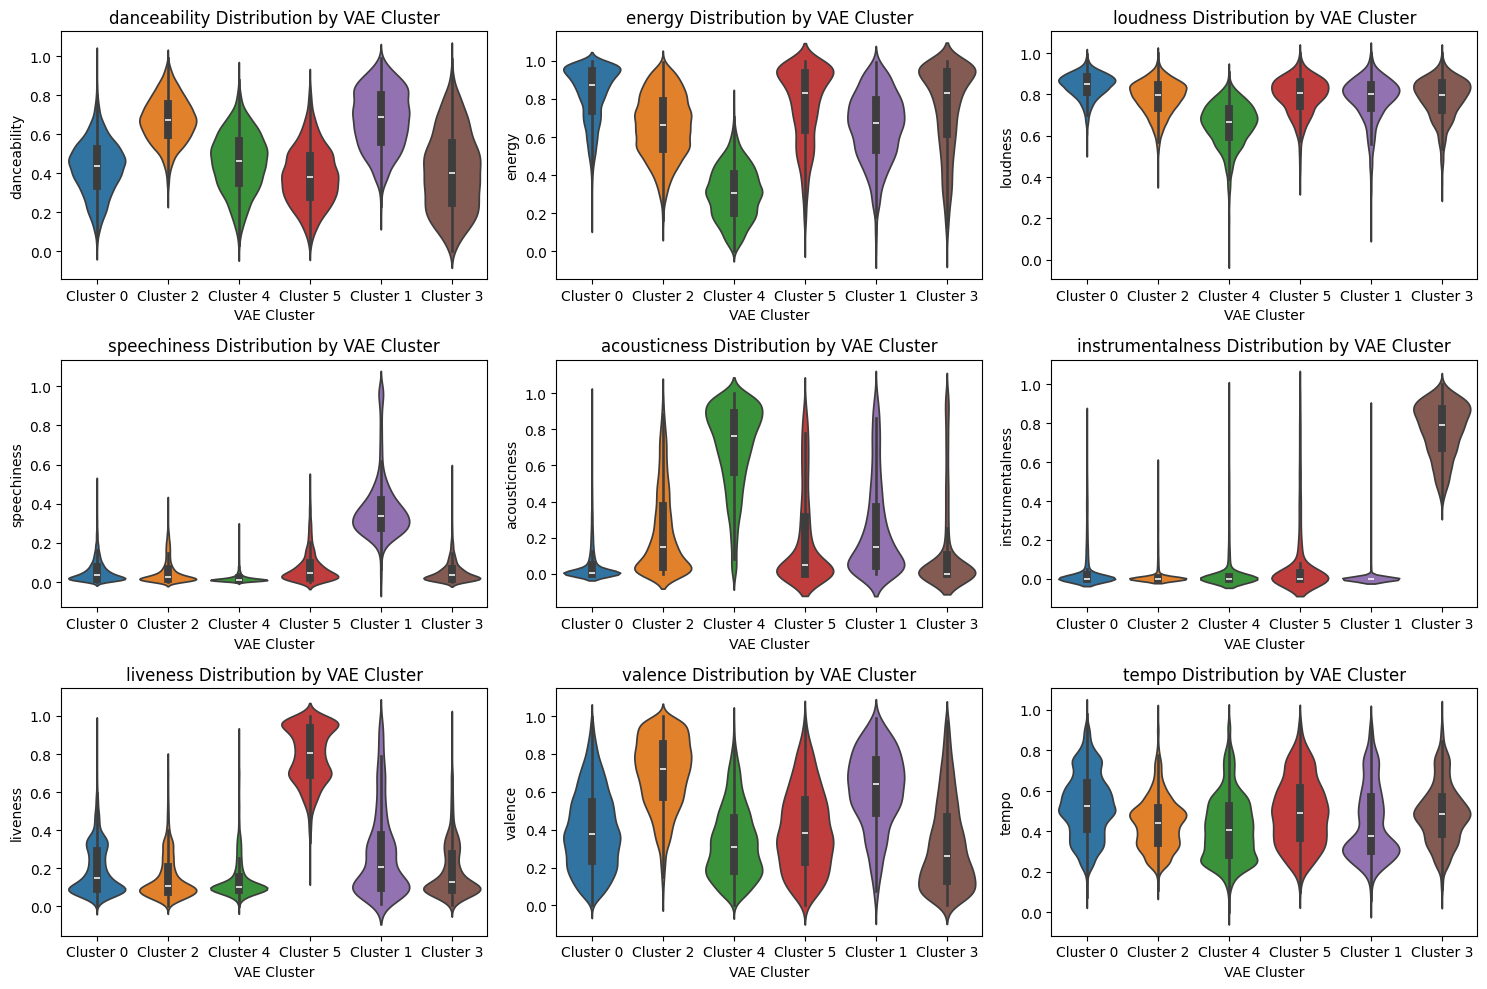

In [31]:
# Create clear cluster labels
df_mm['vae_cluster_label'] = "Cluster " + df_mm['vae_cluster'].astype(str)

# Plot violin plots for each feature
plt.figure(figsize=(15,10))

for i, feature in enumerate(feature_cols):
    plt.subplot(3,3,i+1)
    
    sns.violinplot(
        x='vae_cluster_label',   # clearer cluster names
        y=feature,
        data=df_mm,
        palette='tab10'
    )
    
    plt.title(f"{feature} Distribution by VAE Cluster")
    plt.xlabel("VAE Cluster")
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

In [34]:
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

kmeans_pca = KMeans(n_clusters=6, random_state=42, n_init=20)
clusters_pca = kmeans_pca.fit_predict(X_pca)
df['pca_cluster'] = clusters_pca

sil_pca = silhouette_score(X_pca, clusters_pca)
ch_pca = calinski_harabasz_score(X_pca, clusters_pca)

print("\nPCA + KMeans")
print("Silhouette:", sil_pca)
print("Calinski-Harabasz:", ch_pca)



PCA + KMeans
Silhouette: 0.22934964564498783
Calinski-Harabasz: 6450.595592577482


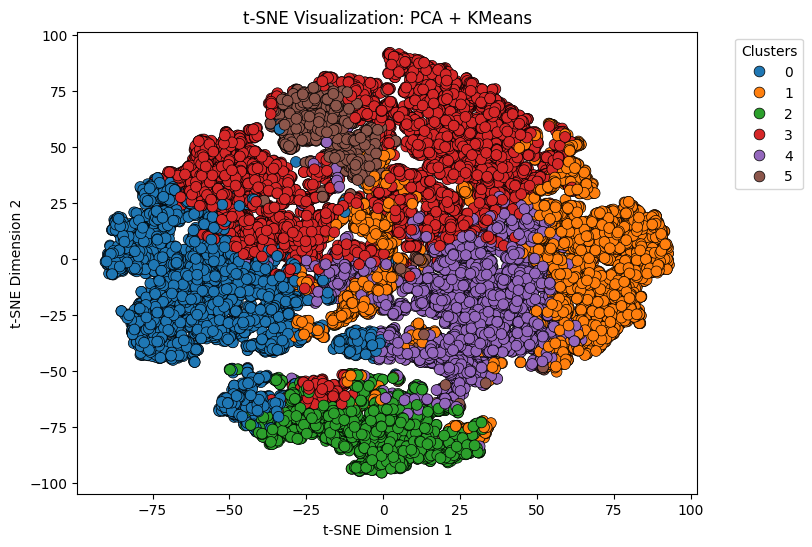

In [37]:
# t-SNE for visualization
tsne_pca = TSNE(n_components=2, perplexity=50, random_state=42)
pca_2d = tsne_pca.fit_transform(X_pca)

plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_2d[:,0], y=pca_2d[:,1], hue=clusters_pca, 
                palette='tab10', edgecolor='black', linewidth=0.5, s=60)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("t-SNE Visualization: PCA + KMeans")
plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


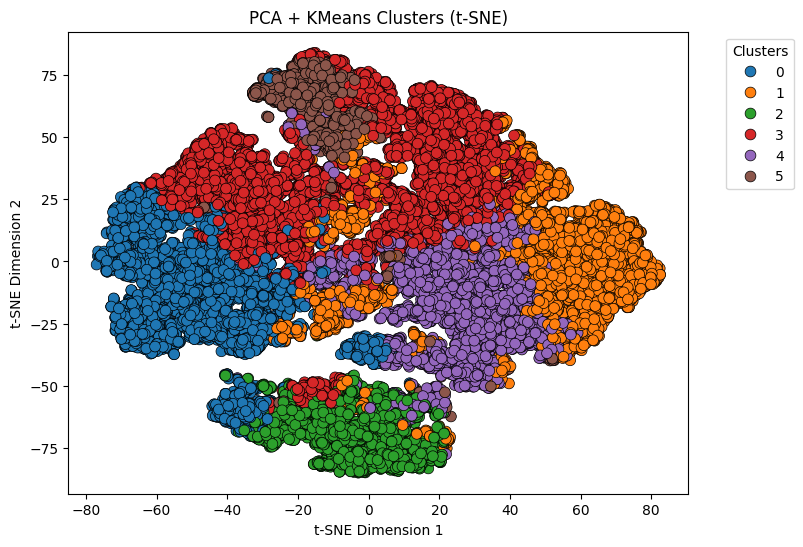

In [38]:
# t-SNE for visualization
tsne_pca = TSNE(n_components=2, perplexity=80, random_state=42)
pca_2d = tsne_pca.fit_transform(X_pca)

plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_2d[:,0], y=pca_2d[:,1], hue=clusters_pca, 
                palette='tab10', edgecolor='black', linewidth=0.5, s=60)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("PCA + KMeans Clusters (t-SNE)")
plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


             danceability    energy  loudness  speechiness  acousticness  \
pca_cluster                                                                
0                0.469716  0.305813  0.645930     0.024622      0.711132   
1                0.399596  0.824799  0.841277     0.058792      0.077211   
2                0.396290  0.803001  0.799151     0.057546      0.070886   
3                0.658772  0.686463  0.796846     0.043622      0.186907   
4                0.403968  0.840258  0.842824     0.065754      0.063825   
5                0.665249  0.673748  0.782854     0.351567      0.246435   

             instrumentalness  liveness   valence     tempo  
pca_cluster                                                  
0                    0.070255  0.172938  0.361744  0.422713  
1                    0.031909  0.197544  0.475297  0.673587  
2                    0.727270  0.188475  0.302046  0.493546  
3                    0.032891  0.136489  0.652907  0.431434  
4                  

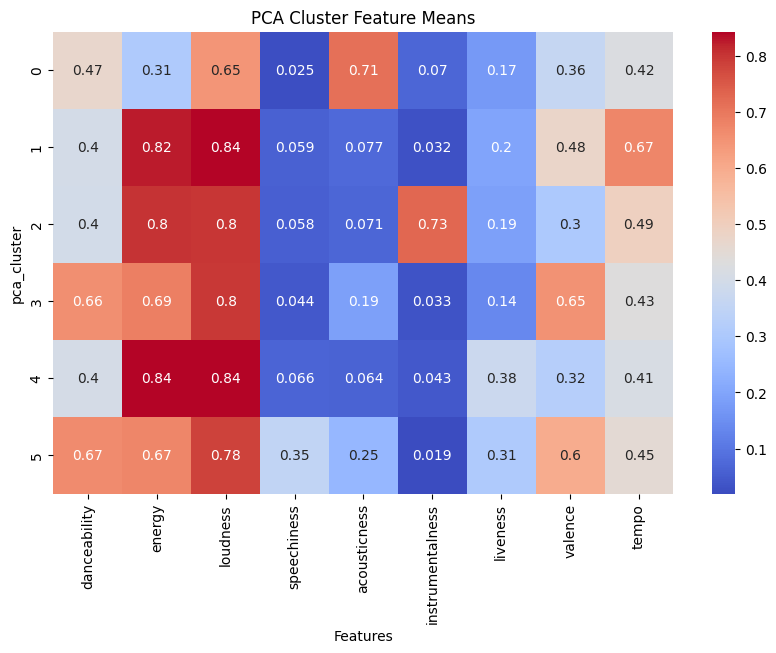

(PCA) Each Cluster Size: 


pca_cluster
3    7203
0    4943
1    4453
4    4389
2    2395
5    1617
Name: count, dtype: int64

In [ ]:
scaler_mm = MinMaxScaler()
df_mm1 = df.copy()
df_mm1[feature_cols] = scaler_mm.fit_transform(df[feature_cols])

cluster_summary_pca = df_mm1.groupby('pca_cluster')[feature_cols].mean()
print(cluster_summary_pca)

# heatmap visualization
plt.figure(figsize=(10,6))
sns.heatmap(cluster_summary_pca, annot=True, cmap='coolwarm')
plt.xlabel("Features")
plt.title("PCA Cluster Feature Means")
plt.show()

# Check cluster size
print("(PCA) Each Cluster Size: ")
df['pca_cluster'].value_counts()


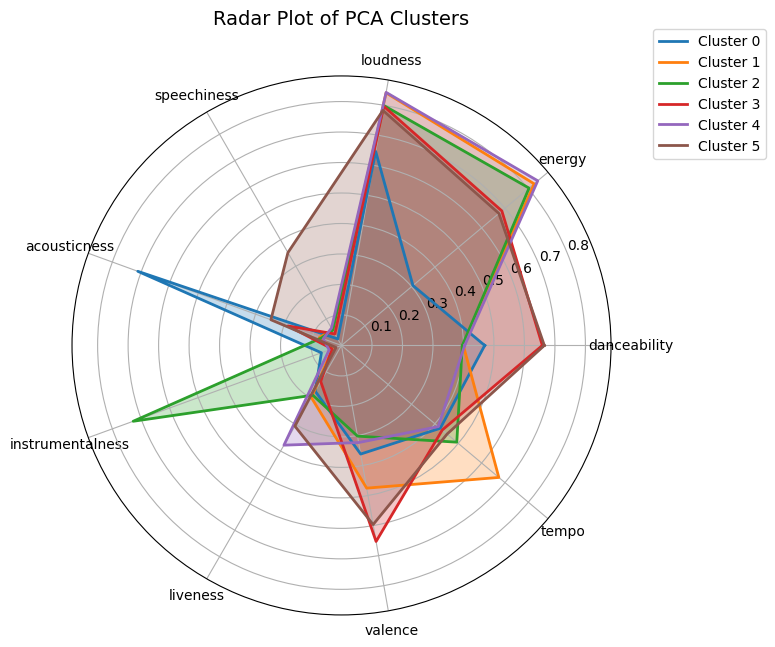

In [45]:
# Radar / Spider Plot

labels = feature_cols
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(7,7))

colors = sns.color_palette("tab10", len(cluster_summary_pca))
for i, color in zip(cluster_summary_pca.index, colors):
    values = cluster_summary_pca.loc[i].values.tolist()
    values += values[:1]
    plt.polar(angles, values, label=f"Cluster {i}", color=color, linewidth=2)

    plt.fill(angles, values, color=color, alpha=0.25)


plt.xticks(angles[:-1], labels, rotation=45)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.title("Radar Plot of PCA Clusters", size=14, color='black', y=1.08)
plt.show()


             danceability    energy  loudness  speechiness  acousticness  \
pca_cluster                                                                
0               -0.036052 -0.367370 -0.136379    -0.043083      0.468987   
1               -0.106171  0.151615  0.058969    -0.008913     -0.164934   
2               -0.109477  0.129818  0.016842    -0.010159     -0.171258   
3                0.153005  0.013279  0.014537    -0.024082     -0.055238   
4               -0.101799  0.167075  0.060516    -0.001950     -0.178320   
5                0.159481  0.000564  0.000545     0.283862      0.004290   

             instrumentalness  liveness   valence     tempo  
pca_cluster                                                  
0                   -0.037324 -0.039902 -0.106864 -0.054400  
1                   -0.075669 -0.015297  0.006689  0.196474  
2                    0.619692 -0.024366 -0.166562  0.016434  
3                   -0.074687 -0.076352  0.184299 -0.045678  
4                  

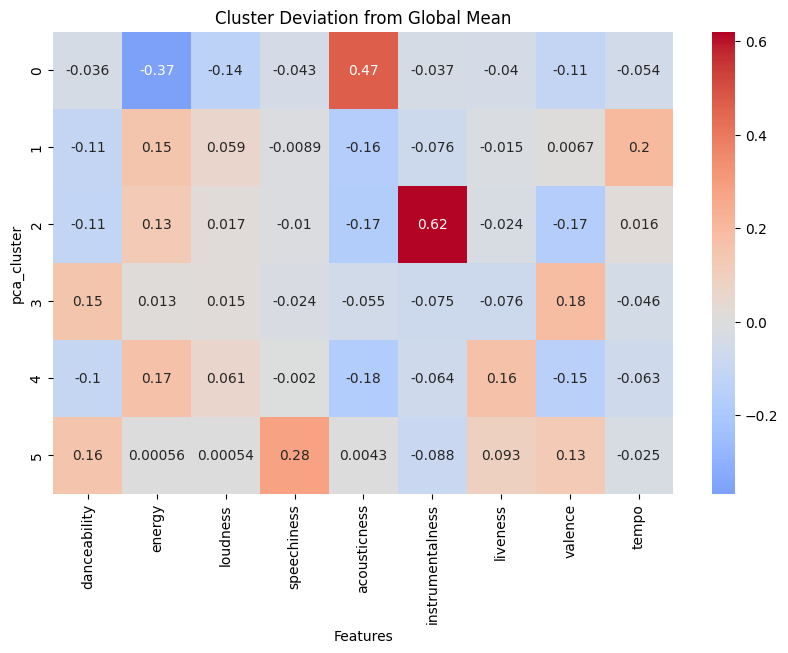

In [47]:
# Feature Importance per Cluster (Difference from Global Mean)
overall_mean = df_mm1[feature_cols].mean()
diff = cluster_summary_pca - overall_mean
print(diff)

plt.figure(figsize=(10,6))
sns.heatmap(diff, annot=True, cmap='coolwarm', center=0)
plt.xlabel("Features")
plt.title("Cluster Deviation from Global Mean")
plt.show()


Min: -0.1724156693294106
Max: 0.5181130605674675


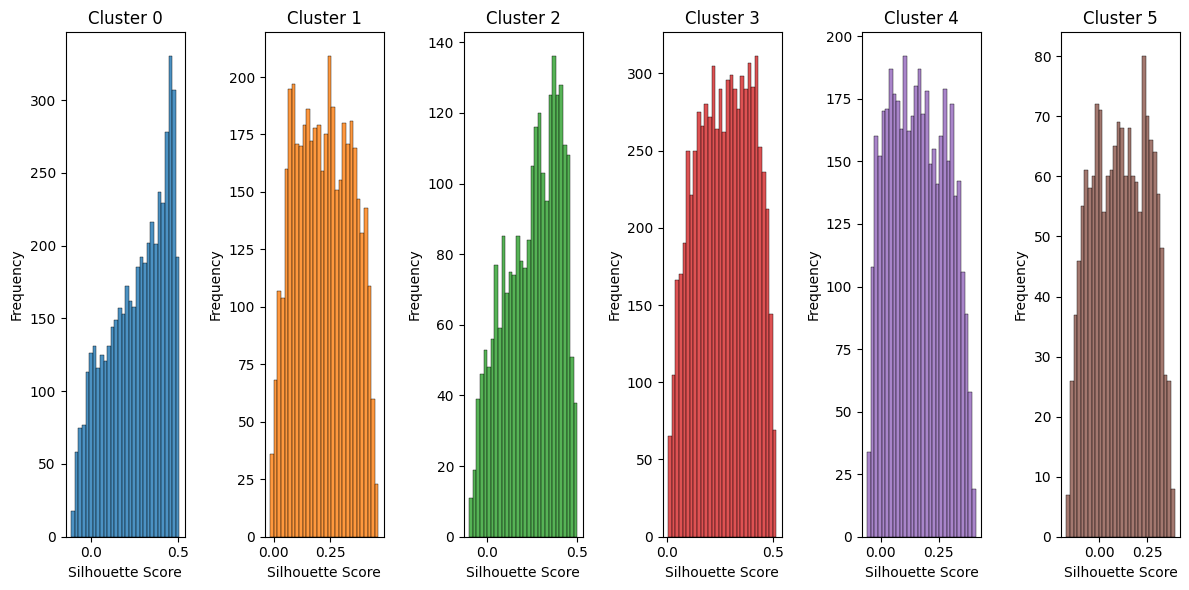

In [58]:
# Silhouette Plot (show silhouette per sample)
from sklearn.metrics import silhouette_samples
sil_pca = silhouette_samples(X_pca, clusters_pca)

print("Min:", sil_pca.min())
print("Max:", sil_pca.max())

unique_clusters = np.unique(clusters_pca)
colors = sns.color_palette("tab10", len(unique_clusters))

plt.figure(figsize=(12, 6))

for i, c in enumerate(unique_clusters):
    plt.subplot(1, len(unique_clusters), i+1)
    
    sns.histplot(
        sil_pca[clusters_pca == c],
        bins=30,
        color=colors[i],   
        edgecolor='black',
        alpha=0.8
    )
    
    plt.title(f'Cluster {c}')
    plt.xlabel("Silhouette Score")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


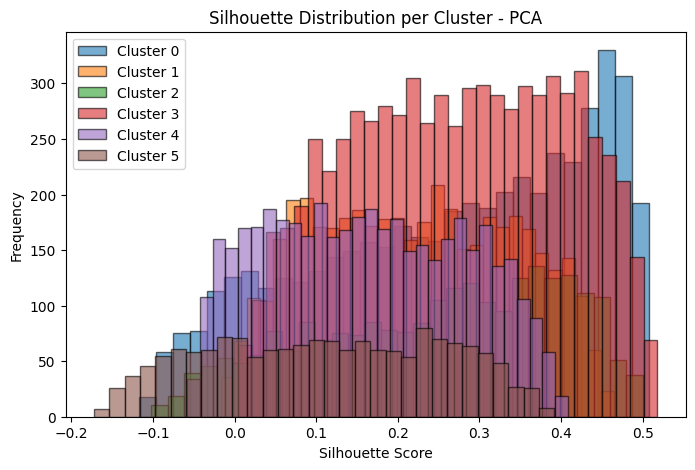

In [50]:

from sklearn.metrics import silhouette_samples

unique_clusters = np.unique(clusters_pca)

plt.figure(figsize=(8,5))

for c in unique_clusters:
    plt.hist(
        sil_pca[clusters_pca == c],
        bins=30,
        alpha=0.6,
        edgecolor='black',
        label=f'Cluster {c}'
    )

plt.title("Silhouette Distribution per Cluster - PCA")
plt.xlabel("Silhouette Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()


Average silhouette score (red dashed line): 0.22934964564498783
Cluster 0 average silhouette: 0.26392989078121104
Cluster 1 average silhouette: 0.22109824551322005
Cluster 2 average silhouette: 0.24723929790312446
Cluster 3 average silhouette: 0.27212110193224215
Cluster 4 average silhouette: 0.16250599254420353
Cluster 5 average silhouette: 0.11077302829336365


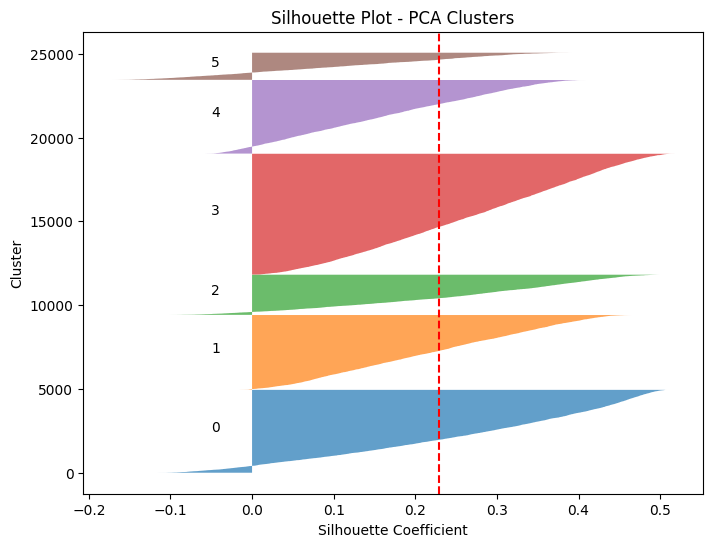

In [51]:
'''
This shows:
Thickness -> cluster size
Width -> cluster compactness
Negative area -> bad separation
Red line -> average silhouette score
'''
y_lower = 10
unique_clusters = np.unique(clusters_pca)

plt.figure(figsize=(8,6))

for c in unique_clusters:
    cluster_sil_pca = sil_pca[clusters_pca == c]
    cluster_sil_pca.sort()
    
    size_cluster = cluster_sil_pca.shape[0]
    y_upper = y_lower + size_cluster
    
    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_sil_pca,
        alpha=0.7
    )
    
    plt.text(-0.05, y_lower + 0.5 * size_cluster, str(c))
    
    y_lower = y_upper + 10

avg_silhouette = np.mean(sil_pca)
print("Average silhouette score (red dashed line):", avg_silhouette)
for c in np.unique(clusters_pca):
    cluster_avg = sil_pca[clusters_pca == c].mean()
    print(f"Cluster {c} average silhouette:", cluster_avg)
plt.axvline(x=np.mean(sil_pca), color="red", linestyle="--")
plt.title("Silhouette Plot - PCA Clusters")
plt.xlabel("Silhouette Coefficient")
plt.ylabel("Cluster")
plt.show()


/tmp/ipykernel_55/1816421667.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_55/1816421667.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_55/1816421667.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_55/1816421667.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_55/1816421667.py:10: FutureWarning: 


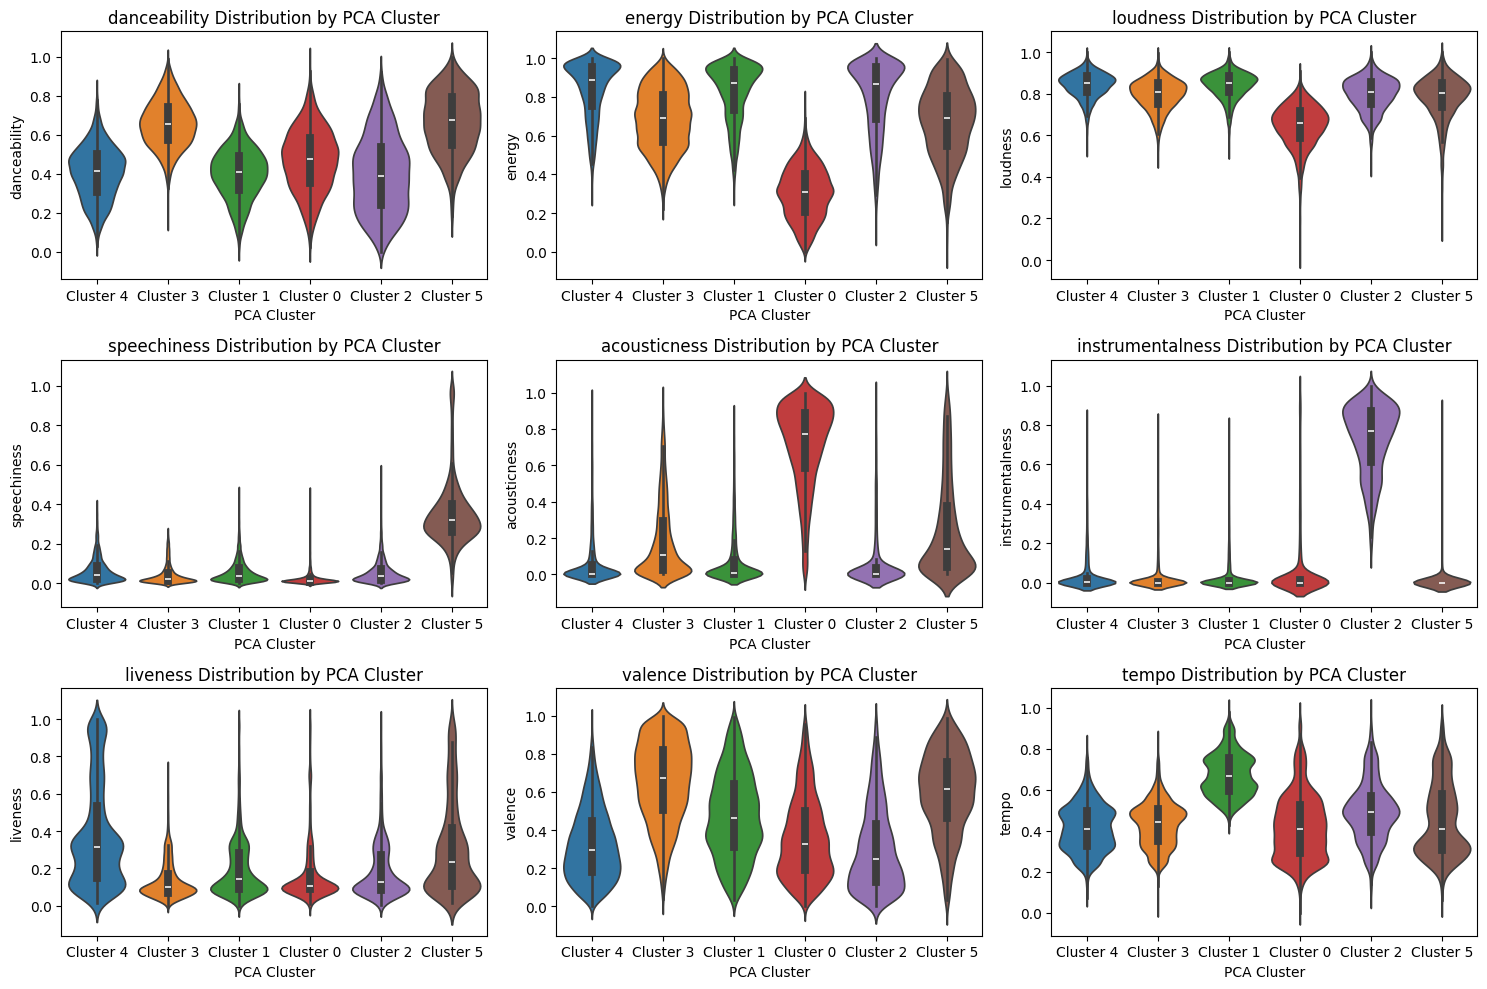

In [52]:
# Create clear cluster labels
df_mm1['pca_cluster_label'] = "Cluster " + df_mm1['pca_cluster'].astype(str)

# Plot violin plots for each feature
plt.figure(figsize=(15,10))

for i, feature in enumerate(feature_cols):
    plt.subplot(3,3,i+1)
    
    sns.violinplot(
        x='pca_cluster_label',   # clearer cluster names
        y=feature,
        data=df_mm1,
        palette='tab10'
    )
    
    plt.title(f"{feature} Distribution by PCA Cluster")
    plt.xlabel("PCA Cluster")
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

2026-03-06 01:12:46.486381: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772759566.691782      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772759566.750347      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772759567.219133      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772759567.219175      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772759567.219178      55 computation_placer.cc:177] computation placer alr

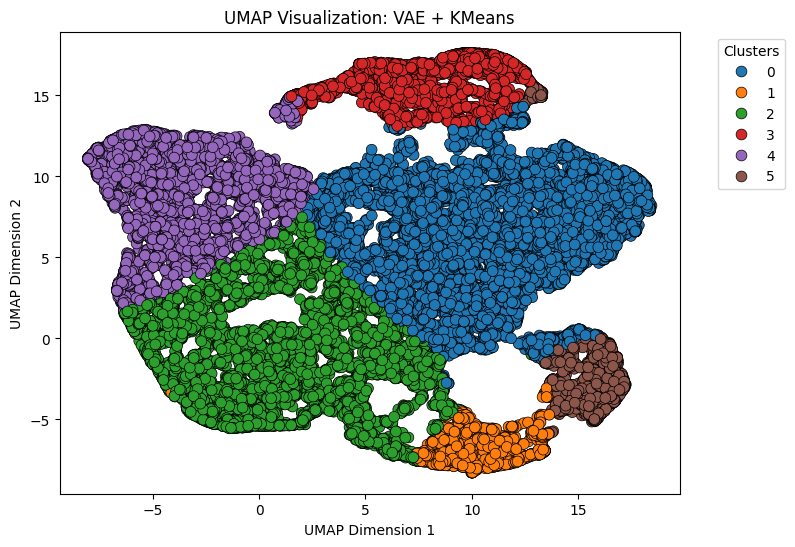

In [53]:
import umap
# KMeans
kmeans_vae = KMeans(n_clusters=best_k, random_state=42, n_init = 20)
clusters_vae = kmeans_vae.fit_predict(latent_features_best)

# UMAP 2D
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
vae_umap_2d = reducer.fit_transform(latent_features_best)

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x = vae_umap_2d[:,0], y =vae_umap_2d[:,1], hue=clusters_vae, palette='tab10', edgecolor='black', linewidth=0.5, s=60)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Visualization: VAE + KMeans")
plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()



/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


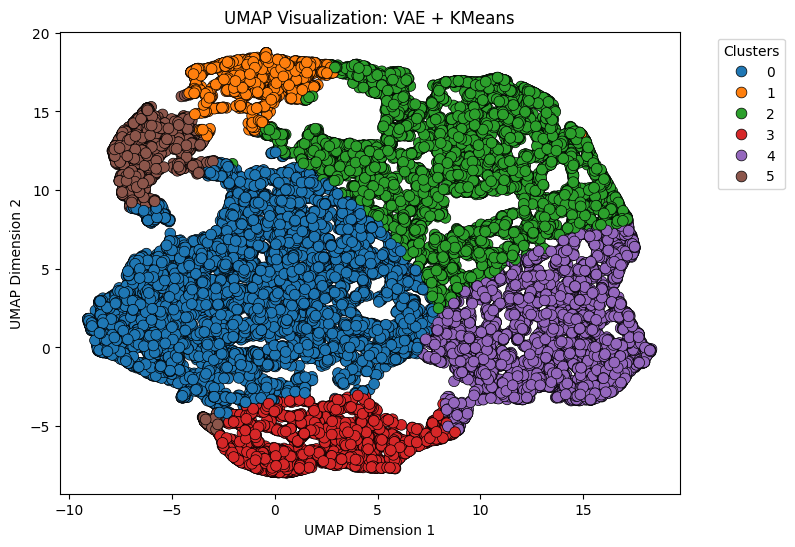

In [55]:
import umap
# KMeans
kmeans_vae = KMeans(n_clusters=best_k, random_state=42, n_init = 20)
clusters_vae = kmeans_vae.fit_predict(latent_features_best)

# UMAP 2D
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
vae_umap_2d = reducer.fit_transform(latent_features_best)

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x = vae_umap_2d[:,0], y =vae_umap_2d[:,1], hue=clusters_vae, palette='tab10', edgecolor='black', linewidth=0.5, s=60)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Visualization: VAE + KMeans")
plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()



/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


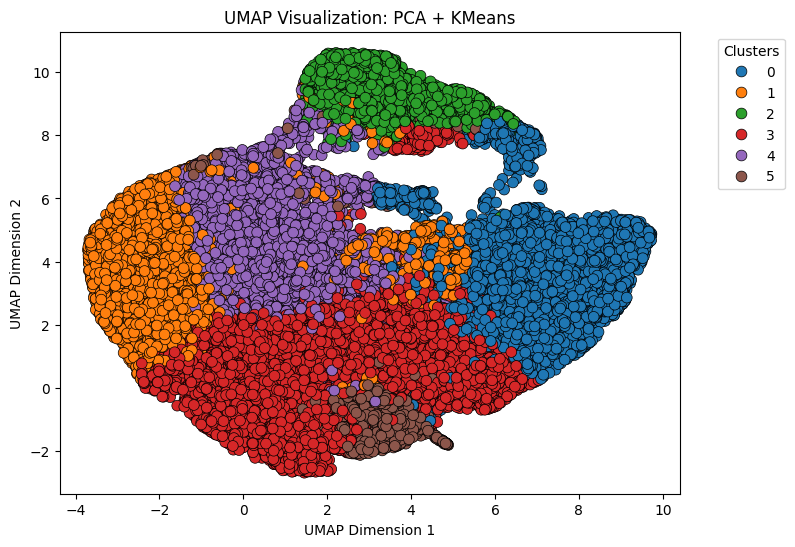

In [56]:
# Reduce input features via PCA first
pca = PCA(n_components=5)  # same as VAE latent_dim for fair comparison
# KMeans
kmeans_pca = KMeans(n_clusters=6, random_state=42, n_init = 20)
clusters_pca = kmeans_pca.fit_predict(X_pca)

# UMAP 2D
reducer_pca = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
pca_umap_2d = reducer_pca.fit_transform(X_pca)

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_umap_2d[:,0], y=pca_umap_2d[:,1], hue=clusters_pca, palette='tab10', edgecolor='black', linewidth=0.5, s=60)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Visualization: PCA + KMeans")
plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


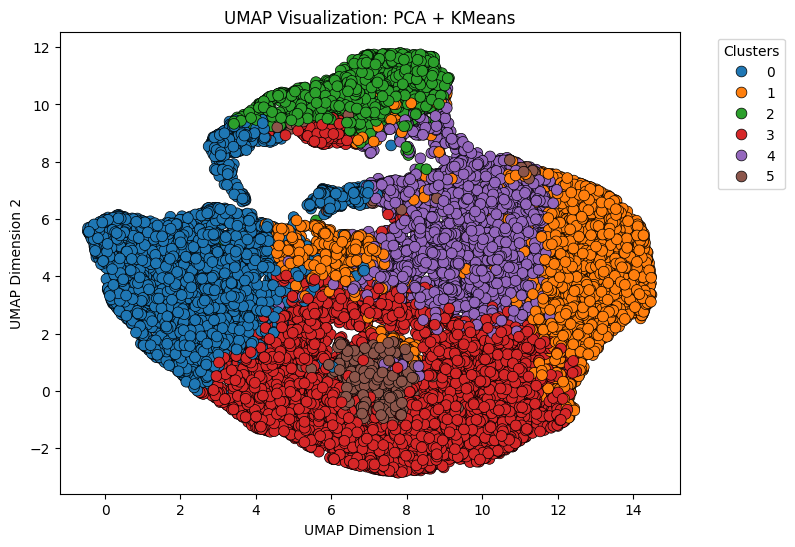

In [57]:
# Reduce input features via PCA first
pca = PCA(n_components=5)  # same as VAE latent_dim for fair comparison
# KMeans
kmeans_pca = KMeans(n_clusters=6, random_state=42, n_init = 20)
clusters_pca = kmeans_pca.fit_predict(X_pca)

# UMAP 2D
reducer_pca = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
pca_umap_2d = reducer_pca.fit_transform(X_pca)

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_umap_2d[:,0], y=pca_umap_2d[:,1], hue=clusters_pca, palette='tab10', edgecolor='black', linewidth=0.5, s=60)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Visualization: PCA + KMeans")
plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()
